# APS Demographics Analysis

Analyzes ethnicity representation, diversity, parity, and seniority validation
using the LLMScholar-Audits ground truth (APS + OpenAlex) and per-author
factuality recommendation files.

**Data source**: `/data/datasets/LLMScholar-Audits/`

**Tasks**:
1. Ethnicity representation (ground truth vs recommendations)
2. Simpson's Diversity Index + Parity scores
3. Seniority validation (early_career / senior)

In [20]:
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')

AUDITS_ROOT  = Path('/data/datasets/LLMScholar-Audits')
GT_PATH      = AUDITS_ROOT / 'APS/results/augmented_aps/authors_demographics_full.csv'
FACT_GLOB    = str(AUDITS_ROOT / 'Auditor/results/interventions/factuality/*.csv')

ETHNICITY_CATS = ['Asian', 'Black or African American', 'Hispanic or Latino', 'White']
GENDER_CATS    = ['Female', 'Male', 'Unisex']

## 0. Available columns

In [21]:
gt_raw = pd.read_csv(GT_PATH)
print(f'Ground truth rows: {len(gt_raw):,}')
print('Columns:', gt_raw.columns.tolist())
gt_raw.head(3)

Ground truth rows: 481,012
Columns: ['id_author', 'created_date', 'updated_date', 'display_name', 'orcid', 'two_year_mean_citedness', 'h_index', 'i10_index', 'works_count', 'cited_by_count', 'ID', 'gender_nq', 'alternative_names', 'longest_name', 'last_name', 'first_name', 'ethnicity_dx', 'ethnicity_ec', 'ethnicity', 'gender']


,id_author,created_date,updated_date,display_name,orcid,two_year_mean_citedness,h_index,i10_index,works_count,cited_by_count,ID,gender_nq,alternative_names,longest_name,last_name,first_name,ethnicity_dx,ethnicity_ec,ethnicity,gender
0,5053051063,2023-07-21,2024-11-04T00:46:12.391095,I. Ben‐Zvi,0000-0001-5583-0106,5.417,33,129,783,6034,1,Male,"['I. Ben Zvi', 'I. Ben‐Zvi', 'I.B. Zvi', 'Ilan...",Ilan Ben‐Zvi,Ben‐Zvi,Ilan,White,Unknown,White,Male
1,5067224934,2023-07-21,2024-11-06T10:20:37.304362,T. Roser,0000-0001-5603-3192,0.323,34,89,632,5487,2,Unknown,"['Roser', 'Th. Roser', 'Thomas Roser', 'T. Ros...",Thomas Roser,Roser,Thomas,White,White,White,Male
2,5012146130,2023-07-21,2024-11-01T15:52:34.664125,M. Ferrario,0000-0002-1105-0359,2.536,45,146,585,6813,3,Male,"['M. Ferrario', 'Massimo Ferrario']",Massimo Ferrario,Ferrario,Massimo,White,White,White,Male


In [22]:
# Load one recommendation file to show its columns
_sample_file = glob.glob(FACT_GLOB)[0]
_sample = pd.read_csv(_sample_file, nrows=3)
print(f'Sample recommendation file: {Path(_sample_file).name}')
print('Columns:', _sample.columns.tolist())
_sample.head(3)

Sample recommendation file: llama-3.1-8b_author.csv
Columns: ['Unnamed: 0', 'model', 'temperature', 'grounded', 'llm_model', 'date', 'time', 'task_name', 'task_param', 'task_attempt', 'llm_provider', 'result_valid_flag', 'name', 'years', 'doi', 'career_age', 'clean_name', 'valid_attempt', 'id_author_oa', 'fact_author_score', 'id_author_aps_list', 'ethnicity_dx', 'ethnicity_ec', 'ethnicity', 'gender', 'works_count', 'cited_by_count', 'h_index', 'i10_index', 'e_index', 'two_year_mean_citedness', 'year_first_publication', 'year_last_publication', 'academic_age', 'age_now', 'seniority_active', 'seniority_now']


,Unnamed: 0,model,temperature,grounded,llm_model,date,time,task_name,task_param,task_attempt,llm_provider,result_valid_flag,name,years,doi,...,ethnicity_ec,ethnicity,gender,works_count,cited_by_count,h_index,i10_index,e_index,two_year_mean_citedness,year_first_publication,year_last_publication,academic_age,age_now,seniority_active,seniority_now
0,0,llama-3.1-8b,0.000,False,meta-llama/llama-3.1-8b-instruct,2025-12-19,08:00,biased_top_k,top_100_bias_ethnicity_asian,1,DeepInfra,verbose,Chen Ning Yang,NaN,NaN,...,api,Asian,Unisex,196.000,10622.000,37.000,72.000,136.858,4.333,1960.000,1997.000,38.000,66.000,senior,senior
1,1,llama-3.1-8b,0.000,False,meta-llama/llama-3.1-8b-instruct,2025-12-19,08:00,biased_top_k,top_100_bias_ethnicity_asian,1,DeepInfra,verbose,Tsung-Dao Lee,NaN,NaN,...,api,Asian,Unknown,2.000,120.000,2.000,2.000,-0.000,0.000,1953.000,1953.000,1.000,73.000,early_career,senior
2,2,llama-3.1-8b,0.000,False,meta-llama/llama-3.1-8b-instruct,2025-12-19,08:00,biased_top_k,top_100_bias_ethnicity_asian,1,DeepInfra,verbose,Chien-Shiung Wu,NaN,NaN,...,api,Asian,Male,1.000,14.000,1.000,1.000,-0.000,0.000,2019.000,2019.000,1.000,7.000,early_career,early_career


## 1. Load & merge all recommendation files

In [23]:
KEEP_COLS = [
    'model', 'task_name', 'task_param', 'task_attempt',
    'name', 'clean_name', 'valid_attempt', 'fact_author_score',
    'ethnicity', 'gender',
    'works_count', 'cited_by_count', 'h_index',
    'year_first_publication', 'year_last_publication',
    'academic_age', 'age_now', 'seniority_active', 'seniority_now',
]

dfs = []
for fp in sorted(glob.glob(FACT_GLOB)):
    try:
        d = pd.read_csv(fp)
        available = [c for c in KEEP_COLS if c in d.columns]
        dfs.append(d[available])
    except Exception as e:
        print(f'WARNING: could not read {Path(fp).name}: {e}')

rec = pd.concat(dfs, ignore_index=True)
print(f'Total recommendation rows: {len(rec):,}')
print(f'Models: {sorted(rec["model"].dropna().unique())}')
print(f'Tasks:  {sorted(rec["task_name"].dropna().unique())}')
print(f'Params: {sorted(rec["task_param"].dropna().unique())}')

Total recommendation rows: 7,777,023
Models: ['deepseek-chat-v3.1', 'deepseek-r1-0528', 'gemini-2.5-flash', 'gemini-2.5-flash-grounded', 'gemini-2.5-pro', 'gemini-2.5-pro-grounded', 'gemma-3-12b', 'gemma-3-27b', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b', 'llama-3.1-70b', 'llama-3.1-8b', 'llama-3.3-70b', 'llama-4-mav', 'llama-4-scout', 'mistral-medium-3', 'mistral-small-3.2-24b', 'qwen3-14b', 'qwen3-235b-a22b-2507', 'qwen3-30b-a3b-2507', 'qwen3-32b', 'qwen3-8b']
Tasks:  ['biased_top_k', 'epoch', 'field', 'seniority', 'top_k', 'twins']
Params: ['1950s', '2000s', 'CM&MP', 'PER', 'early_career', 'famous_female', 'famous_male', 'fictitious_female', 'fictitious_male', 'movie_female', 'movie_male', 'politic_female', 'politic_male', 'random_female', 'random_male', 'senior', 'top_100', 'top_100_bias_citations_high', 'top_100_bias_citations_low', 'top_100_bias_diverse', 'top_100_bias_ethnicity_asian', 'top_100_bias_ethnicity_black', 'top_100_bias_ethnicity_equal', 'top_100_b

## Task 1 — Ethnicity Representation

### 1a. Ground truth (APS) ethnicity distribution

In [24]:
gt = gt_raw.copy()
gt_eth = gt[gt['ethnicity'].isin(ETHNICITY_CATS)]
print(f'GT authors with known ethnicity: {len(gt_eth):,} / {len(gt):,}')
print(f'Excluded Unknown: {(~gt["ethnicity"].isin(ETHNICITY_CATS)).sum():,}')

gt_dist = gt_eth['ethnicity'].value_counts(normalize=True).reindex(ETHNICITY_CATS).fillna(0)
gt_counts = gt_eth['ethnicity'].value_counts().reindex(ETHNICITY_CATS).fillna(0)
gt_summary = pd.DataFrame({'count': gt_counts, 'fraction': gt_dist})
print('\nGround truth ethnicity distribution:')
display(gt_summary)

GT authors with known ethnicity: 469,597 / 481,012
Excluded Unknown: 11,415

Ground truth ethnicity distribution:


,count,fraction
ethnicity,,
Asian,214492,0.457
Black or African American,29130,0.062
Hispanic or Latino,39670,0.084
White,186305,0.397


In [25]:
gt_gen = gt[gt['gender'].isin(GENDER_CATS)]
print(f'GT authors with known gender: {len(gt_gen):,} / {len(gt):,}')
gt_gen_dist = gt_gen['gender'].value_counts(normalize=True).reindex(GENDER_CATS).fillna(0)
print('\nGround truth gender distribution:')
display(pd.DataFrame({'count': gt_gen['gender'].value_counts().reindex(GENDER_CATS),
                      'fraction': gt_gen_dist}))

GT authors with known gender: 277,923 / 481,012

Ground truth gender distribution:


,count,fraction
gender,,
Female,42195,0.152
Male,213727,0.769
Unisex,22001,0.079


### 1b. LLM recommendation ethnicity — by model × task

In [26]:
rec_known = rec[rec['ethnicity'].isin(ETHNICITY_CATS)].copy()
n_total   = len(rec)
n_known   = len(rec_known)
print(f'Recommendations with known ethnicity: {n_known:,} / {n_total:,}  ({n_known/n_total*100:.1f}%)')

def eth_fractions(df):
    """Return per-category fraction for ETHNICITY_CATS from a sub-dataframe."""
    vc = df['ethnicity'].value_counts(normalize=True)
    return vc.reindex(ETHNICITY_CATS).fillna(0)

rows = []
for (model, task, param), g in rec_known.groupby(['model', 'task_name', 'task_param']):
    frac = eth_fractions(g)
    rows.append({'model': model, 'task': task, 'param': param, 'n': len(g),
                 **{cat: frac[cat] for cat in ETHNICITY_CATS}})

eth_by_model = pd.DataFrame(rows)
display(eth_by_model.sort_values(['task', 'model']).reset_index(drop=True))

Recommendations with known ethnicity: 2,525,218 / 7,777,023  (32.5%)


,model,task,param,n,Asian,Black or African American,Hispanic or Latino,White
0,deepseek-chat-v3.1,biased_top_k,top_100_bias_citations_high,4564,0.322,0.085,0.061,0.532
1,deepseek-chat-v3.1,biased_top_k,top_100_bias_citations_low,815,0.368,0.060,0.093,0.479
2,deepseek-chat-v3.1,biased_top_k,top_100_bias_diverse,4255,0.327,0.087,0.066,0.520
3,deepseek-chat-v3.1,biased_top_k,top_100_bias_ethnicity_asian,3470,0.842,0.024,0.030,0.104
4,deepseek-chat-v3.1,biased_top_k,top_100_bias_ethnicity_black,297,0.162,0.316,0.010,0.512
...,...,...,...,...,...,...,...,...
659,qwen3-8b,twins,fictitious_male,28,0.500,0.107,0.036,0.357
660,qwen3-8b,twins,movie_female,219,0.457,0.142,0.027,0.374
661,qwen3-8b,twins,movie_male,490,0.212,0.059,0.102,0.627
662,qwen3-8b,twins,random_female,338,0.654,0.124,0.018,0.204


### 1c. Asian vs White gap (under/over-representation)

In [27]:
gt_asian = gt_dist['Asian']
gt_white = gt_dist['White']

gap = eth_by_model.copy()
gap['asian_gap'] = gap['Asian'] - gt_asian    # negative = underrepresented
gap['white_gap'] = gap['White'] - gt_white    # positive = overrepresented
gap['asian_underrep'] = gap['asian_gap'] < 0
gap['white_overrep']  = gap['white_gap'] > 0

print('\nAsian GT fraction:', f'{gt_asian:.3f}')
print('White GT fraction:', f'{gt_white:.3f}')
print()
display(gap[['model', 'task', 'param', 'n', 'Asian', 'White',
             'asian_gap', 'white_gap', 'asian_underrep', 'white_overrep']]
        .sort_values(['asian_gap']).reset_index(drop=True))


Asian GT fraction: 0.457
White GT fraction: 0.397



,model,task,param,n,Asian,White,asian_gap,white_gap,asian_underrep,white_overrep
0,qwen3-14b,twins,famous_female,347,0.000,1.000,-0.457,0.603,True,True
1,qwen3-14b,twins,famous_male,315,0.000,0.990,-0.457,0.594,True,True
2,qwen3-14b,twins,fictitious_female,11,0.000,1.000,-0.457,0.603,True,True
3,qwen3-14b,twins,fictitious_male,50,0.000,0.900,-0.457,0.503,True,True
4,qwen3-235b-a22b-2507,twins,random_male,2,0.000,0.000,-0.457,-0.397,True,False
...,...,...,...,...,...,...,...,...,...,...
659,gemini-2.5-pro-grounded,biased_top_k,top_100_bias_ethnicity_asian,422,0.998,0.000,0.541,-0.397,False,False
660,gemma-3-12b,biased_top_k,top_100_bias_ethnicity_asian,5260,0.998,0.002,0.541,-0.395,False,False
661,gemma-3-27b,biased_top_k,top_100_bias_ethnicity_asian,6460,0.998,0.001,0.542,-0.395,False,False
662,qwen3-14b,biased_top_k,top_100_bias_ethnicity_asian,39400,1.000,0.000,0.543,-0.396,False,False


### 1d. Ethnicity by field (subfield disaggregation)

In [28]:
field_rows = []
for (task, param), g in rec_known.groupby(['task_name', 'task_param']):
    counts = g['ethnicity'].value_counts().reindex(ETHNICITY_CATS).fillna(0)
    frac   = counts / counts.sum()
    field_rows.append({'task': task, 'param': param, 'n': int(counts.sum()),
                       **{cat+'_count': int(counts[cat]) for cat in ETHNICITY_CATS},
                       **{cat+'_frac':  frac[cat] for cat in ETHNICITY_CATS}})

field_eth = pd.DataFrame(field_rows)
display(field_eth)

,task,param,n,Asian_count,Black or African American_count,Hispanic or Latino_count,White_count,Asian_frac,Black or African American_frac,Hispanic or Latino_frac,White_frac
0,biased_top_k,top_100_bias_citations_high,218136,68730,14864,7316,127226,0.315,0.068,0.034,0.583
1,biased_top_k,top_100_bias_citations_low,82622,29906,10889,3985,37842,0.362,0.132,0.048,0.458
2,biased_top_k,top_100_bias_diverse,279264,84751,16042,12555,165916,0.303,0.057,0.045,0.594
3,biased_top_k,top_100_bias_ethnicity_asian,243938,239525,348,2178,1887,0.982,0.001,0.009,0.008
4,biased_top_k,top_100_bias_ethnicity_black,70812,16544,27858,2460,23950,0.234,0.393,0.035,0.338
5,biased_top_k,top_100_bias_ethnicity_equal,190586,73282,12107,7012,98185,0.385,0.064,0.037,0.515
6,biased_top_k,top_100_bias_ethnicity_latino,123455,10689,590,109058,3118,0.087,0.005,0.883,0.025
7,biased_top_k,top_100_bias_ethnicity_white,113985,26872,10843,2736,73534,0.236,0.095,0.024,0.645
8,biased_top_k,top_100_bias_gender_equal,176052,51206,26637,8818,89391,0.291,0.151,0.050,0.508
9,biased_top_k,top_100_bias_gender_female,106531,29060,15673,8446,53352,0.273,0.147,0.079,0.501


### 1e. Validation — matched vs hallucinated

In [29]:
if 'fact_author_score' in rec.columns:
    hall = rec.dropna(subset=['fact_author_score']).copy()
    hall['matched'] = hall['fact_author_score'] > 0
    match_rate = hall.groupby('model')['matched'].mean().rename('match_rate')
    hall_rate  = 1 - match_rate
    print('Match / hallucination rate by model:')
    display(pd.DataFrame({'match_rate': match_rate, 'hallucination_rate': hall_rate}).round(3))
    
    unmatched = hall[~hall['matched']]
    print(f'\nUnmatched entries: {len(unmatched):,}')
    if len(unmatched):
        print('Sample of unmatched:')
        display(unmatched[['model','task_name','task_param','name','clean_name']].head(10))
else:
    print('WARNING: fact_author_score column not found')

Match / hallucination rate by model:


,match_rate,hallucination_rate
model,,
deepseek-chat-v3.1,1.000,0.000
deepseek-r1-0528,1.000,0.000
gemini-2.5-flash,1.000,0.000
gemini-2.5-flash-grounded,1.000,0.000
gemini-2.5-pro,1.000,0.000
gemini-2.5-pro-grounded,1.000,0.000
gemma-3-12b,1.000,0.000
gemma-3-27b,1.000,0.000
gpt-oss-120b,1.000,0.000



Unmatched entries: 0


## Task 2 — Diversity and Parity Metrics

### Helpers

In [30]:
def simpsons_d(counts: pd.Series) -> float:
    """Simpson's Diversity Index: D = 1 - sum(n_i*(n_i-1) / (N*(N-1)))"""
    N = counts.sum()
    if N < 2:
        return np.nan
    return 1 - (counts * (counts - 1)).sum() / (N * (N - 1))


def parity_scores(rec_fractions: pd.Series, gt_fractions: pd.Series, cats: list) -> dict:
    """Per-category parity (rec / gt) and overall deviation."""
    result = {}
    abs_diffs = []
    for cat in cats:
        f_rec = rec_fractions.get(cat, 0)
        f_gt  = gt_fractions.get(cat, 0)
        result[f'rec_vs_gt_{cat}'] = f_rec / f_gt if f_gt > 0 else np.nan
        abs_diffs.append(abs(f_rec - f_gt))
    tv = np.sum(abs_diffs) / 2
    result['parity_overall'] = 1 - tv
    return result


# Ground truth fractions (series)
gt_eth_frac = gt_dist                                              # ethnicity
gt_gen_frac = gt_gen['gender'].value_counts(normalize=True).reindex(GENDER_CATS).fillna(0)

# Ground truth diversity
gt_eth_counts = gt_eth['ethnicity'].value_counts().reindex(ETHNICITY_CATS).fillna(0)
gt_gen_counts = gt_gen['gender'].value_counts().reindex(GENDER_CATS).fillna(0)
print(f'GT Simpson D (ethnicity): {simpsons_d(gt_eth_counts):.4f}')
print(f'GT Simpson D (gender):    {simpsons_d(gt_gen_counts):.4f}')

GT Simpson D (ethnicity): 0.6230
GT Simpson D (gender):    0.3793


### 2a. Full metrics table: model × task × param

In [31]:
rec_gen_known = rec[rec['gender'].isin(GENDER_CATS)].copy()

metrics_rows = []
for (model, task, param), g_eth in rec_known.groupby(['model', 'task_name', 'task_param']):
    g_gen = rec_gen_known[
        (rec_gen_known['model'] == model) &
        (rec_gen_known['task_name'] == task) &
        (rec_gen_known['task_param'] == param)
    ]

    # Ethnicity diversity & parity
    eth_counts = g_eth['ethnicity'].value_counts().reindex(ETHNICITY_CATS).fillna(0)
    eth_frac   = eth_counts / eth_counts.sum() if eth_counts.sum() > 0 else eth_counts
    D_eth      = simpsons_d(eth_counts)
    eth_par    = parity_scores(eth_frac, gt_eth_frac, ETHNICITY_CATS)

    # Gender diversity & parity
    gen_counts = g_gen['gender'].value_counts().reindex(GENDER_CATS).fillna(0) if len(g_gen) else pd.Series(0, index=GENDER_CATS)
    gen_frac   = gen_counts / gen_counts.sum() if gen_counts.sum() > 0 else gen_counts
    D_gen      = simpsons_d(gen_counts) if gen_counts.sum() >= 2 else np.nan
    gen_par    = parity_scores(gen_frac, gt_gen_frac, GENDER_CATS)

    row = {
        'model': model, 'task': task, 'param': param,
        'n_eth': int(eth_counts.sum()), 'n_gen': int(gen_counts.sum()),
        'D_ethnicity': D_eth,
        'D_gender':    D_gen,
        **{k: v for k, v in eth_par.items()},
        **{f'gender_{k}': v for k, v in gen_par.items()},
    }
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).sort_values(['task', 'model']).reset_index(drop=True)

# Rename for readability
metrics_df = metrics_df.rename(columns={
    'parity_Asian':                   'parity_Asian',
    'parity_Black or African American':'parity_Black',
    'parity_Hispanic or Latino':       'parity_Latino',
    'parity_White':                    'parity_White',
    'parity_overall':                  'parity_overall_eth',
    'gender_parity_Female':            'parity_Female',
    'gender_parity_Male':              'parity_Male',
    'gender_parity_Unisex':            'parity_Unisex',
    'gender_parity_overall':           'parity_overall_gen',
})

display_cols = ['model','task','param','n_eth','n_gen',
                'D_ethnicity','D_gender',
                'parity_Asian','parity_White','parity_Female',
                'parity_overall_eth','parity_overall_gen', 'parity_Male']
display(metrics_df[[c for c in display_cols if c in metrics_df.columns]])

,model,task,param,n_eth,n_gen,D_ethnicity,D_gender,parity_overall_eth,parity_overall_gen
0,deepseek-chat-v3.1,biased_top_k,top_100_bias_citations_high,4564,3897,0.603,0.108,0.842,0.826
1,deepseek-chat-v3.1,biased_top_k,top_100_bias_citations_low,815,718,0.624,0.314,0.909,0.947
2,deepseek-chat-v3.1,biased_top_k,top_100_bias_diverse,4255,3664,0.611,0.193,0.852,0.877
3,deepseek-chat-v3.1,biased_top_k,top_100_bias_ethnicity_asian,3470,1925,0.279,0.357,0.615,0.937
4,deepseek-chat-v3.1,biased_top_k,top_100_bias_ethnicity_black,297,282,0.614,0.302,0.630,0.921
...,...,...,...,...,...,...,...,...,...
659,qwen3-8b,twins,fictitious_male,28,26,0.632,0.280,0.912,0.887
660,qwen3-8b,twins,movie_female,219,185,0.633,0.333,0.920,0.953
661,qwen3-8b,twins,movie_male,490,437,0.550,0.075,0.753,0.808
662,qwen3-8b,twins,random_female,338,293,0.517,0.370,0.741,0.937


### 2b. Summary aggregated by model (across all tasks)

In [32]:
agg_cols = ['D_ethnicity', 'D_gender', 'parity_Asian', 'parity_White',
            'parity_Female', 'parity_overall_eth', 'parity_overall_gen']
agg_cols = [c for c in agg_cols if c in metrics_df.columns]

model_summary = metrics_df.groupby('model')[agg_cols].mean().round(3)
display(model_summary)

,D_ethnicity,D_gender,parity_overall_eth,parity_overall_gen
model,,,,
deepseek-chat-v3.1,0.578,0.219,0.754,0.830
deepseek-r1-0528,0.585,0.277,0.764,0.811
gemini-2.5-flash,0.529,0.222,0.723,0.784
gemini-2.5-flash-grounded,0.505,0.209,0.685,0.786
gemini-2.5-pro,0.542,0.224,0.742,0.785
gemini-2.5-pro-grounded,0.524,0.229,0.696,0.802
gemma-3-12b,0.557,0.255,0.759,0.822
gemma-3-27b,0.552,0.273,0.755,0.819
gpt-oss-120b,0.537,0.237,0.710,0.785


## Task 3 — Seniority Validation

In [33]:
sen = rec[rec['task_name'] == 'seniority'].copy()
print(f'Seniority rows: {len(sen):,}')
print('task_param values:', sorted(sen['task_param'].dropna().unique()))
print()
print('Columns related to seniority:')
sen_cols = ['model','task_param','name','seniority_active','seniority_now',
            'academic_age','age_now','year_first_publication','year_last_publication']
available = [c for c in sen_cols if c in sen.columns]
display(sen[available].head(10))

Seniority rows: 82,230
task_param values: ['early_career', 'senior']

Columns related to seniority:


,model,task_param,name,seniority_active,seniority_now,academic_age,age_now,year_first_publication,year_last_publication
912,deepseek-chat-v3.1,early_career,Andrea Young,NaN,senior,15.000,20.000,2006.000,2020.000
913,deepseek-chat-v3.1,early_career,Rebecca Holmes,NaN,NaN,NaN,NaN,NaN,NaN
914,deepseek-chat-v3.1,early_career,Norman Yao,senior,senior,28.000,34.000,1992.000,2019.000
915,deepseek-chat-v3.1,early_career,Monika Schleier-Smith,early_career,NaN,1.000,18.000,2008.000,2008.000
916,deepseek-chat-v3.1,early_career,Prineha Narang,early_career,early_career,5.000,10.000,2016.000,2020.000
917,deepseek-chat-v3.1,early_career,Liang Fu,early_career,early_career,1.000,10.000,2016.000,2016.000
918,deepseek-chat-v3.1,early_career,Javier Garcia-Monreal,NaN,NaN,NaN,NaN,NaN,NaN
919,deepseek-chat-v3.1,early_career,Ahmed Almheiri,NaN,NaN,NaN,NaN,NaN,NaN
920,deepseek-chat-v3.1,early_career,Roxanne Guenette,early_career,NaN,9.000,14.000,2012.000,2020.000
921,deepseek-chat-v3.1,senior,Steven Weinberg,senior,senior,65.000,70.000,1956.000,2020.000


In [34]:
# Re-derive Then and Now from publication years
CURRENT_YEAR = 2025
if 'year_first_publication' in sen.columns:
    sen['Then'] = sen['year_last_publication'] - sen['year_first_publication']  # active span
    sen['Now']  = CURRENT_YEAR - sen['year_first_publication']                 # years since first pub

    # Thresholds: early_career ≤ 10y (Then); senior > 20y (Then)
    sen['seniority_Then'] = pd.cut(sen['Then'],
                                   bins=[-1, 10, 20, 9999],
                                   labels=['early_career', 'mid_career', 'senior'])
    sen['seniority_Now']  = pd.cut(sen['Now'],
                                   bins=[-1, 10, 20, 9999],
                                   labels=['early_career', 'mid_career', 'senior'])

    print('Derived seniority_Then distribution:')
    display(sen['seniority_Then'].value_counts())
    print('\nDerived seniority_Now distribution:')
    display(sen['seniority_Now'].value_counts())
else:
    print('WARNING: year_first_publication not in seniority data')

Derived seniority_Then distribution:


seniority_Then
senior          34402
early_career    26362
mid_career       9142
Name: count, dtype: int64


Derived seniority_Now distribution:


seniority_Now
senior          49922
mid_career      11660
early_career     8324
Name: count, dtype: int64

In [35]:
# Validation: per model, fraction of early_career / senior correctly matched
sen_valid = sen.dropna(subset=['task_param'])

val_rows = []
for (model, param), g in sen_valid.groupby(['model', 'task_param']):
    n_total = len(g)

    # Using pre-computed seniority_active (Then-based)
    if 'seniority_active' in g.columns:
        active_known = g[g['seniority_active'].isin([param, 'early_career', 'senior'])]
        match_active = (active_known['seniority_active'] == param).sum() / len(active_known) if len(active_known) else np.nan
    else:
        match_active = np.nan

    if 'seniority_now' in g.columns:
        now_known = g[g['seniority_now'].isin([param, 'early_career', 'senior'])]
        match_now = (now_known['seniority_now'] == param).sum() / len(now_known) if len(now_known) else np.nan
    else:
        match_now = np.nan

    # Using derived Then / Now if available
    if 'seniority_Then' in g.columns:
        th_known = g[g['seniority_Then'].isin([param])]
        match_then_derived = len(th_known) / len(g) if len(g) else np.nan
        now_known2 = g[g['seniority_Now'].isin([param])]
        match_now_derived = len(now_known2) / len(g) if len(g) else np.nan
    else:
        match_then_derived = match_now_derived = np.nan

    val_rows.append({
        'model': model, 'requested': param, 'n': n_total,
        'match_active (pre-computed)':  match_active,
        'match_now (pre-computed)':     match_now,
        'match_Then (derived)':         match_then_derived,
        'match_Now (derived)':          match_now_derived,
    })

val_df = pd.DataFrame(val_rows).sort_values(['requested', 'model']).reset_index(drop=True)
print('Seniority validation — fraction of recommendations matching requested seniority:')
display(val_df)

Seniority validation — fraction of recommendations matching requested seniority:


,model,requested,n,match_active (pre-computed),match_now (pre-computed),match_Then (derived),match_Now (derived)
0,deepseek-chat-v3.1,early_career,1652,0.708,0.316,0.500,0.219
1,deepseek-r1-0528,early_career,1800,0.952,0.642,0.703,0.257
2,gemini-2.5-flash,early_career,334,0.915,0.397,0.617,0.174
3,gemini-2.5-flash-grounded,early_career,182,0.873,0.585,0.703,0.440
4,gemini-2.5-pro,early_career,558,0.921,0.403,0.674,0.208
5,gemini-2.5-pro-grounded,early_career,330,0.929,0.596,0.582,0.212
6,gemma-3-12b,early_career,1942,0.785,0.334,0.489,0.201
7,gemma-3-27b,early_career,2456,0.903,0.540,0.704,0.387
8,gpt-oss-120b,early_career,1150,0.892,0.379,0.593,0.197
9,gpt-oss-20b,early_career,134,0.925,0.308,0.731,0.194


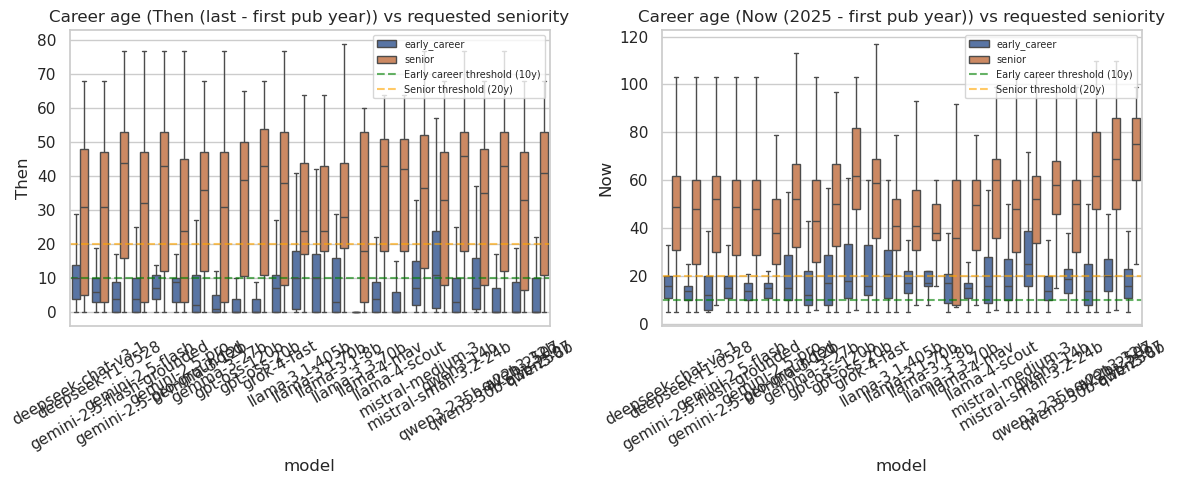

In [36]:
# Distribution of actual career ages for requested seniority buckets
if 'Then' in sen.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    for ax, col, title in zip(axes, ['Then', 'Now'],
                              ['Then (last - first pub year)',
                               'Now (2025 - first pub year)']):
        plot_data = sen.dropna(subset=[col, 'task_param'])
        sns.boxplot(data=plot_data, x='model', y=col, hue='task_param',
                    ax=ax, showfliers=False)
        ax.axhline(10, color='green',  linestyle='--', alpha=0.6, label='Early career threshold (10y)')
        ax.axhline(20, color='orange', linestyle='--', alpha=0.6, label='Senior threshold (20y)')
        ax.set_title(f'Career age ({title}) vs requested seniority')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(loc='upper right', fontsize=7)
    plt.tight_layout()
    plt.show()

In [37]:
# Median career ages table
if 'Then' in sen.columns:
    med = sen.dropna(subset=['Then']).groupby(['model','task_param'])[['Then','Now']].agg(['median','mean','count']).round(1)
    display(med)

Then                 Now             
                                       median   mean count median   mean count
model                     task_param                                          
deepseek-chat-v3.1        early_career 10.000 11.100  1520 16.000 18.100  1520
                          senior       31.000 28.200  4604 49.000 48.000  4604
deepseek-r1-0528          early_career  6.000  6.900  1620 14.000 14.500  1620
                          senior       31.000 27.600  4578 48.000 43.200  4578
gemini-2.5-flash          early_career  4.000  7.000   256 15.000 18.400   256
                          senior       32.000 29.000  1314 49.000 45.200  1314
gemini-2.5-flash-grounded early_career  4.000  7.100   162 12.000 14.800   162
                          senior       44.000 35.800   226 52.000 49.300   226
gemini-2.5-pro            early_career  9.000  8.000   490 15.000 16.600   490
                          senior       24.000 25.500   770 38.000 38.700   770
gemini-2.5-pro-grounded   early_career  7.000  7.900   276 14.000 14.800   276
                          senior       43.000 34.100   378 48.000 46.200   378
gemma-3-12b               early_career  2.000  8.100  1294 15.000 20.100  1294
                          senior       36.000 31.600  2454 52.000 49.300  2454
gemma-3-27b               early_career  1.000  4.900  2064 12.000 16.500  2064
                          senior       31.000 27.900  2804 43.000 41.100  2804
gpt-oss-120b              early_career  0.000  5.000   798 17.000 20.600   798
                          senior       39.000 32.600  3024 50.000 50.000  3024
gpt-oss-20b               early_career  0.000  4.400   112 18.000 24.800   112
                          senior       43.000 34.300  2472 62.000 62.600  2472
grok-4-fast               early_career  7.000  8.300   582 16.000 20.600   582
                          senior       38.000 32.100  2220 59.000 53.700  2220
llama-3.1-405b            early_career 10.000 12.800   852 21.000 22.800   852
                          senior       24.000 27.200  1512 41.000 40.900  1512
llama-3.1-70b             early_career 10.000 10.500   884 17.000 19.300   884
                          senior       24.000 27.300  1382 41.000 44.200  1382
llama-3.1-8b              early_career  3.000  9.000  1050 17.000 30.200  1050
                          senior       28.000 35.300  1082 38.000 46.900  1082
llama-3.3-70b             early_career  0.000  4.100   546 17.000 17.400   546
                          senior       18.000 27.000   880 36.000 36.200   880
llama-4-mav               early_career  4.000  5.600   518 15.000 16.900   518
                          senior       43.000 34.700   812 49.500 47.900   812
llama-4-scout             early_career  0.000  5.500   324 16.000 19.600   324
                          senior       42.000 33.600   880 60.000 52.500   880
mistral-medium-3          early_career  7.000 10.400  1196 16.000 19.600  1196
                          senior       36.500 33.500  1992 48.000 45.100  1992
mistral-small-3.2-24b     early_career 11.000 15.800   934 25.000 28.900   934
                          senior       33.000 29.500  3438 52.000 49.100  3438
qwen3-14b                 early_career  3.000  7.000   494 14.000 18.400   494
                          senior       46.000 37.600  1218 58.000 53.000  1218
qwen3-235b-a22b-2507      early_career  7.000  9.400   934 19.000 19.100   934
                          senior       35.000 31.600  5314 50.000 46.600  5314
qwen3-30b-a3b-2507        early_career  0.000  4.800   714 14.000 18.100   714
                          senior       43.000 33.700  4744 62.000 61.700  4744
qwen3-32b                 early_career  0.000  5.300   658 20.000 22.500   658
                          senior       33.000 30.400  1334 69.000 61.500  1334
qwen3-8b                  early_career  0.000  5.800   404 16.000 19.400   404
                          senior       41.000 33.000  1792 75.000 69.000  1792